In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Goff and gratch

def compute_gg_es(tboil, t):

## LIQUID ##
    
    term1 = -7.90298 * (tboil / t - 1.0)
    term2 = 5.02808 * math.log10(tboil / t)
    term3 = -1.3816e-7 * (10.0 ** (11.344 * (1.0 - t / tboil)) - 1.0)
    term4 = 8.1328e-3 * (10.0 ** (-3.49149 * (tboil / t - 1.0)) - 1.0)
    term5 = math.log10(1013.246)
    
  
 
    
    es = 10.0 ** (term1 + term2 + term3 + term4 + term5) * 100.0
    return es

In [3]:
# shr_flux_mod.F90

def compute_qsat_shr(Tk):
    return 640380.0 / math.exp(5107.4 / Tk)



In [4]:
def qsat_from_esat(esat, p):
    epsilon = 0.622
    return (epsilon * esat) / (p - (1 - epsilon) * esat)


In [5]:
def qsat_over_ice(TsfK):
    """
    Calculate saturation specific humidity over ice (qsat) in kg/m^3
    based on surface temperature in Kelvin.

    Parameters:
    TsfK (float): Surface temperature in Kelvin

    Returns:
    float: Saturation specific humidity over ice (kg/m^3)
    """
    qqqice = 11637800.0  # constant for qsat over ice
    TTTice = 5897.8      # constant for qsat over ice

    qsat = qqqice * math.exp(-TTTice / TsfK)
    return qsat

Temp =  [220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304]
qsat_shr %diff =  [-49.98, -49.16, -48.34, -47.5, -46.67, -45.82, -44.98, -44.12, -43.26, -42.4, -41.52, -40.65, -39.77, -38.88, -37.99, -37.09, -36.19, -35.28, -34.36, -33.45, -32.52, -31.59, -30.66, -29.72, -28.78, -27.83, -26.88, -25.92, -24.96, -23.99, -23.02, -22.05, -21.07, -20.08, -19.09, -18.1, -17.1, -16.1, -15.09, -14.08, -13.07, -12.05, -11.03, -10.0, -8.97, -7.94, -6.9, -5.86, -4.81, -3.76, -2.71, -1.65, -0.59, 0.47, 1.54, 2.61, 3.68, 4.76, 5.84, 6.93, 8.01, 9.11, 10.2, 11.3, 12.4, 13.5, 14.6, 15.71, 16.83, 17.94, 19.06, 20.18, 21.3, 22.43, 23.56, 

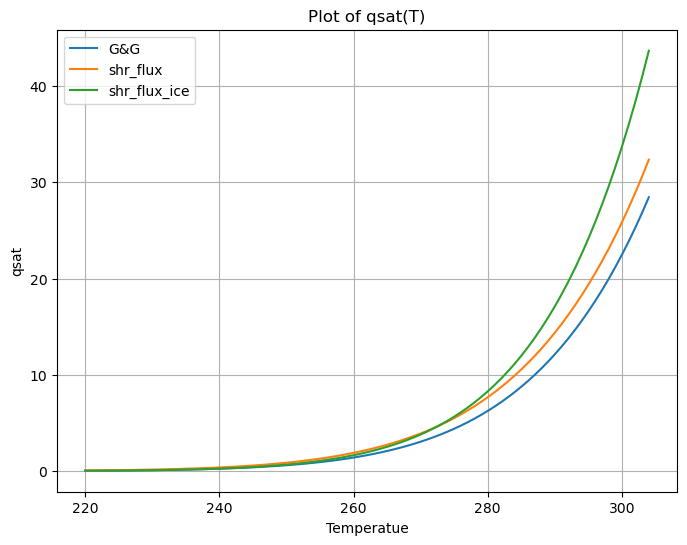

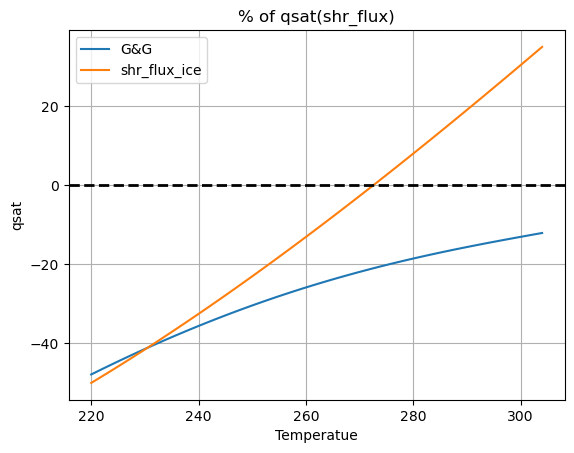

In [23]:
plt.figure(figsize=(8, 6))


p = 99000.0
tboil_in = 373.16

temps = list(range(220, 305,1))


esat_gg = []
qsat_gg = []
qsat_shr = []
qsat_ice = []

for temp in temps: 

    esat = compute_gg_es(tboil_in, temp)
    esat_gg.append(esat)
    qsat_gg.append(1000.*qsat_from_esat(esat, p))
    qsat_shr.append(1000.*compute_qsat_shr(temp))
    qsat_ice.append(1000.*qsat_over_ice(temp))




print('Temp = ',[round(v, 2) for v in temps])
#print('esat_gg = ',[round(v, 2) for v in esat_gg])
#print('qsat_gg = ',[1000.*round(v, 4) for v in qsat_gg])
#print('qsat_shr = ',[1000.*round(v, 4) for v in qsat_shr])
#print('qsat_ice = ',[1000.*round(v, 4) for v in qsat_ice])

qsat_per_gg = 100*(np.array(qsat_gg)-np.array(qsat_shr))/np.array(qsat_shr)
print('qsat_shr %diff = ',[round(v, 2) for v in qsat_per])
qsat_per_ice = 100*(np.array(qsat_ice)-np.array(qsat_shr))/np.array(qsat_shr)
print('qsat_shr %diff = ',[round(v, 2) for v in qsat_per])

plt.plot(temps,qsat_gg, label='G&G')
plt.plot(temps,qsat_shr, label='shr_flux')
plt.plot(temps,qsat_ice, label='shr_flux_ice')
plt.title('Plot of qsat(T)')
plt.xlabel('Temperatue')
plt.ylabel('qsat')
plt.grid(True)
plt.legend()
plt.savefig("qsat_comparison.png")
plt.show()

plt.plot(temps,qsat_per_gg, label='G&G')
plt.plot(temps,qsat_per_ice, label='shr_flux_ice')
plt.title('% of qsat(shr_flux)')
plt.xlabel('Temperatue')
plt.ylabel('qsat')
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.grid(True)
plt.legend()
plt.savefig("qsat_comparison.png")
plt.show()

